In [1]:
import pandas as pd
import os
import json
import numpy as np

In [2]:
def parse_result_as_df_recommended(result_file):
    with open(result_file, 'r') as f:
        lines = f.readlines()
    json_data = json.loads(('').join(lines))
    
    # Handle evaluationResult array by extracting comprehensive statistics
    if 'evaluationResult' in json_data and isinstance(json_data['evaluationResult'], list):
        eval_results = json_data['evaluationResult']
        
        # Basic statistics
        json_data['evaluationResult_count'] = len(eval_results)

        # Exact matching statistics
        exact_matches = [item for item in eval_results if item.get('doesMatchExactly', False)]
        json_data['evaluationResult_exact_matches'] = len(exact_matches) > 0
        # json_data['evaluationResult_exact_rate'] = len(exact_matches) / len(eval_results) if eval_results else 0
        
        # Syntactic matching statistics
        syntactic_matches = [item for item in eval_results if item.get('doesMatchSyntactically', False)]
        json_data['evaluationResult_syntactic_matches'] = len(syntactic_matches) > 0
        # json_data['evaluationResult_syntactic_rate'] = len(syntactic_matches) / len(eval_results) if eval_results else 0
        
        # Semantic matching statistics
        semantic_matches = [item for item in eval_results if item.get('doesMatchSemantically', False)]
        json_data['evaluationResult_semantic_matches'] = len(semantic_matches) > 0
        # json_data['evaluationResult_semantic_rate'] = len(semantic_matches) / len(eval_results) if eval_results else 0
        
        # # Top suggestions
        # json_data['evaluationResult_top_suggestion'] = eval_results[0]['suggestion'] if eval_results else None
        # json_data['evaluationResult_top_rank'] = eval_results[0]['rank'] if eval_results else None
        
        # # Average rank of matches
        # if syntactic_matches:
        #     json_data['evaluationResult_avg_syntactic_rank'] = np.mean([item['rank'] for item in syntactic_matches])
        # else:
        #     json_data['evaluationResult_avg_syntactic_rank'] = None
            
        # Remove the original array to avoid DataFrame creation issues
        del json_data['evaluationResult']

        # Delete any key that starts with 'suggestionIn' to avoid redundancy
        keys_to_delete = [key for key in json_data.keys() if key.startswith('suggestionIn')]
        for key in keys_to_delete:
            del json_data[key]
    
    # Handle any other arrays in similar fashion
    for key, value in list(json_data.items()):
        if isinstance(value, list) and key != 'evaluationResult':  # Handle other potential arrays
            json_data[f'{key}_array_length'] = len(value)
            json_data[f'{key}_as_string'] = json.dumps(value)  # Keep as JSON string if needed
            del json_data[key]  # Remove original array
    
    df = pd.DataFrame(json_data, index=[0])
    return df

In [3]:
# Updated data loading code with proper JSON array handling
FORMULA_TEST_RESULT_DIR = '../test-results/formula/multi_term/'

formula_results_df = pd.DataFrame()

print("Loading formula results...")
for root, subdirs, files in os.walk(FORMULA_TEST_RESULT_DIR):
    for file in files:
        if file.endswith('.result.json'):
            try:
                df = parse_result_as_df_recommended(os.path.join(root, file))
                formula_results_df = pd.concat([formula_results_df, df], axis=0, ignore_index=True)
            except Exception as e:
                print(f"Error processing {file}: {e}")

print(f"Formula results loaded: {len(formula_results_df)} records")

Loading formula results...
Formula results loaded: 2432 records
Formula results loaded: 2432 records


In [4]:
formula_results_df = formula_results_df[formula_results_df["preprocessingTime"].notna()].copy()

formula_results_df["preprocessingPlusParsingTime"] = (
    formula_results_df["preprocessingTime"].astype("Int64") + formula_results_df["parsingTime"].astype("Int64")
)
formula_results_df

,modelName,filename,offset,term,line,character,incompletionLine,completionList,completionGenerated,suggestionExists,...,expectedCompletionLine,elapsedTimeInMs,preprocessingTime,parsingTime,generationTime,evaluationResult_count,evaluationResult_exact_matches,evaluationResult_syntactic_matches,evaluationResult_semantic_matches,preprocessingPlusParsingTime
0,class-diagram,completion/class-diagram-complete.als,343,-,19,17,all c: Class -,"*ext.Class, *ext.Class.*ext, *ext.Class.^ext, ...",True,True,...,Object | c in Object.^~ext,11.552583,1,0,6,80,True,False,False,1
1,class-diagram,completion/class-diagram-complete.als,136,.,9,12,no Object.,"*ext.Class, *ext.Object, ^ext.Class, ^ext.Obje...",True,True,...,ext,15.821583,2,1,2,17,True,True,False,3
2,class-diagram,completion/class-diagram-sig.als,56,extends,5,23,one sig Object extends,"Class, Int, String, none, univ",True,True,...,Class {},9.346834,1,0,0,5,True,True,False,1
3,class-diagram,completion/class-diagram-complete.als,357,in,19,31,all c: Class - Object | c in,"*ext.c, *ext.c.*ext, *ext.c.^ext, *ext.c.ext, ...",True,False,...,Object.^~ext,13.611542,1,1,7,107,False,False,False,2
4,class-diagram,completion/class-diagram-complete.als,364,.,19,38,all c: Class - Object | c in Object.,"*ext.c, ^ext.c, ext.c, ~ext.c, *ext.Class, *ex...",True,True,...,^~ext,7.555584,1,0,1,26,True,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2427,smart-home,completion/smart_home-complete.als,5031,.,156,55,all dev : IndoorDevice | some rum : Room | dev...,"devices.dev, ~room.dev, ~roomsToClean.dev, dev...",True,True,...,devices <=> rum in dev.room,61.524125,16,8,2,100,True,False,False,24
2428,smart-home,completion/smart_home-sig.als,1038,extends,61,17,sig Lock extends,"AC, Barometer, Clean, Clock, Device, Dirty, Di...",True,True,...,IndoorDevice {,3.066500,0,0,0,38,True,True,False,0
2429,smart-home,completion/smart_home-complete.als,1898,in,96,72,fact {all dev : Outlet | some pressure : Press...,"dev, dev.filling, dev.filling.~occupation, dev...",True,True,...,dev.sensors },222.406500,18,8,151,3469,True,False,False,26
2430,smart-home,completion/smart_home-complete.als,2836,in,108,55,fact {all dev : Vacuum | some clock : Clock | ...,"clock, clock, clock.id.~value, clock.value.~id...",True,True,...,dev.sensors },220.379250,17,8,151,3469,True,False,False,25


In [5]:
time_cols = ["elapsedTimeInMs", "preprocessingTime", "parsingTime", "generationTime", "preprocessingPlusParsingTime"]

# Ensure numeric (coerce invalid to NaN)
for col in time_cols:
    formula_results_df[col] = pd.to_numeric(formula_results_df[col], errors="coerce")

avg_times_per_model = (
    formula_results_df.groupby("modelName")[time_cols]
    .mean()
    .round(0)
    .astype("Int64")
    .reset_index()
    )

avg_times_per_model

,modelName,elapsedTimeInMs,preprocessingTime,parsingTime,generationTime,preprocessingPlusParsingTime
0,array,27,5,1,2,6
1,bempl,22,2,0,7,2
2,binary-tree,26,2,1,15,2
3,c-tree,11,1,0,4,1
4,class-diagram,11,1,0,3,2
5,classroom,31,4,2,9,5
6,classroom-fol,34,4,2,13,6
7,classroom-rl,15,2,1,5,3
8,courses-v1,42,6,2,7,8
9,courses-v2,32,6,3,4,8


In [6]:
LARGE_MODELS = ["git", "icd", "frankervrep", "java_meta_model", "random_ski_jumping", "modelo-alloy"]

# Keep rows of LARGE_MODELS intact and merge all others into one group
formula_results_df["modelGroup"] = np.where(
    formula_results_df["modelName"].isin(LARGE_MODELS),
    formula_results_df["modelName"],
    "small (avg)",
)

merged_avg_times = (
    formula_results_df.groupby("modelGroup")[time_cols]
    .mean()
    .round(0)
    .astype("Int64")
    .reset_index()
    .rename(columns={"modelGroup": "modelName"})
)

merged_avg_times.drop(columns=["preprocessingTime", "parsingTime"], inplace=True)

merged_avg_times.reset_index(drop=True, inplace=True)
merged_avg_times.style.hide(axis="index")

modelName,elapsedTimeInMs,generationTime,preprocessingPlusParsingTime
frankervrep,48,14,6
git,175,94,37
icd,37,4,15
java_meta_model,127,49,37
modelo-alloy,169,122,12
random_ski_jumping,252,34,31
small (avg),51,17,11


In [7]:
merged_avg_times.to_csv("completion_runtime_breakdown.csv", index=False, sep="\t")

In [8]:
model_stats_df = pd.read_csv("../test-results/model-stats.csv", sep=",")
model_stats_df.head()

,modelName,filename,numSignatures,numRelations,numFunctions,numFacts,numPredicates,numAssertions,numCommands,numOfFormulas
0,graph,completion/graph-complete.als,1,1,0,0,8,0,1,8
1,trash,completion/trash-complete.als,3,1,0,0,10,0,1,10
2,social-media,completion/socialMedia.als,5,5,0,0,8,0,1,8
3,courses,completion/courses-complete.als,6,5,0,0,16,0,1,16
4,lts,completion/lts-complete.als,3,1,0,0,7,0,1,7


In [9]:
avg_times_per_model = avg_times_per_model.merge(model_stats_df, on="modelName", how="left")
avg_times_per_model

,modelName,elapsedTimeInMs,preprocessingTime,parsingTime,generationTime,preprocessingPlusParsingTime,filename,numSignatures,numRelations,numFunctions,numFacts,numPredicates,numAssertions,numCommands,numOfFormulas
0,array,27,5,1,2,6,completion/array-complete.als,2,2,0,3,1,0,2,4
1,bempl,22,2,0,7,2,completion/bempl-complete.als,6,3,0,1,1,1,2,2
2,binary-tree,26,2,1,15,2,completion/binary-tree-2.als,1,2,0,1,3,0,1,4
3,c-tree,11,1,0,4,1,completion/ctree-complete.als,4,2,0,3,0,0,2,4
4,class-diagram,11,1,0,3,2,completion/class-diagram-complete.als,2,1,0,0,4,0,2,6
5,classroom,31,4,2,9,5,completion/classroom-complete.als,5,3,0,0,15,0,1,15
6,classroom-fol,34,4,2,13,6,completion/classroom-fol-complete.als,5,3,0,0,15,0,1,15
7,classroom-rl,15,2,1,5,3,completion/classroom-rl-complete.als,5,3,0,0,15,0,1,15
8,courses-v1,42,6,2,7,8,completion/courses-v1-complete.als,6,5,0,0,15,0,1,15
9,courses-v2,32,6,3,4,8,completion/courses-v2-complete.als,6,5,0,0,15,0,1,15


In [10]:
import pandas as pd

numeric_cols = avg_times_per_model.select_dtypes(include="number").columns.tolist()

if "time_cols" in globals() and isinstance(time_cols, list) and len(time_cols) > 0:
    detected_time_cols = [c for c in time_cols if c in numeric_cols]
else:
    detected_time_cols = [
        c for c in numeric_cols
        if any(k in c.lower() for k in ["time", "runtime", "latency", "ms", "sec", "seconds"])
    ]

other_metric_cols = [c for c in numeric_cols if c not in detected_time_cols]

print("Time columns:")
print(detected_time_cols)
print("\nOther numeric metrics:")
print(other_metric_cols)
print(f"\nCounts -> time: {len(detected_time_cols)}, other metrics: {len(other_metric_cols)}")

Time columns:
['elapsedTimeInMs', 'preprocessingTime', 'parsingTime', 'generationTime', 'preprocessingPlusParsingTime']

Other numeric metrics:
['numSignatures', 'numRelations', 'numFunctions', 'numFacts', 'numPredicates', 'numAssertions', 'numCommands', 'numOfFormulas']

Counts -> time: 5, other metrics: 8


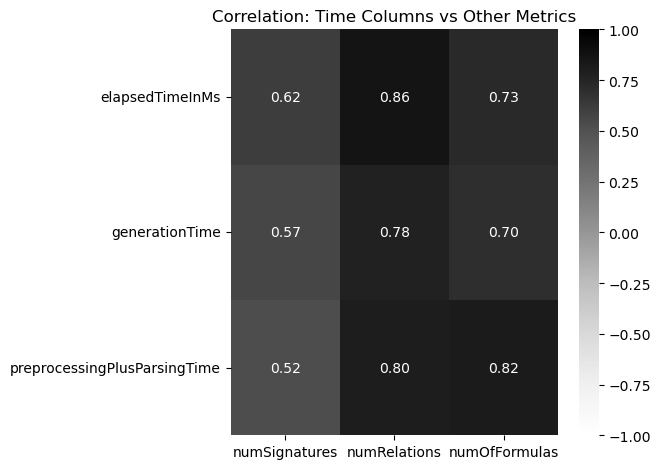

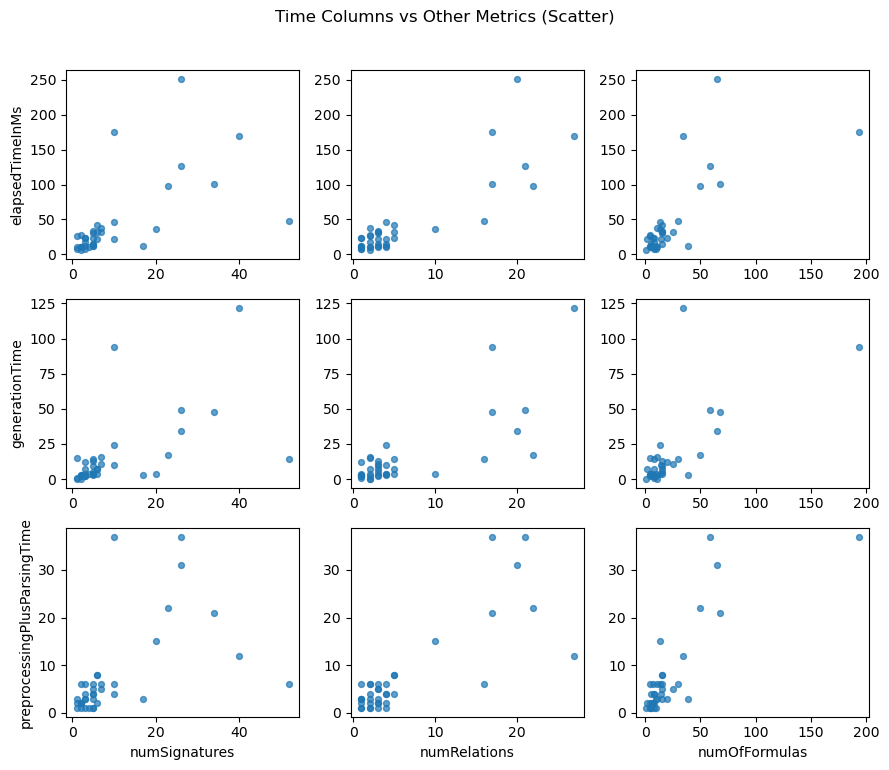

In [11]:
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    _use_seaborn = True
except Exception:
    _use_seaborn = False

# time_cols = detected_time_cols if "detected_time_cols" in globals() else []
# metric_cols = other_metric_cols if "other_metric_cols" in globals() else []

time_cols = ['elapsedTimeInMs', 'generationTime', 'preprocessingPlusParsingTime']
metric_cols = ['numSignatures', 'numRelations', 'numOfFormulas']

if len(time_cols) == 0 or len(metric_cols) == 0:
    print("No time or metric columns available for visualization.")
else:
    max_time = 6
    max_metrics = 6
    selected_time = time_cols[:max_time]
    selected_metrics = metric_cols[:max_metrics]

    subset = avg_times_per_model[selected_time + selected_metrics].dropna()

    # Correlation heatmap: time columns vs other metrics
    corr = subset.corr(numeric_only=True)
    corr_time_vs_metrics = corr.loc[selected_time, selected_metrics]

    plt.figure(figsize=(1.2 * len(selected_metrics) + 3, 0.6 * len(selected_time) + 3))
    if _use_seaborn:
        sns.heatmap(corr_time_vs_metrics, annot=True, fmt=".2f", cmap="Greys", vmin=-1, vmax=1)
    else:
        plt.imshow(corr_time_vs_metrics, cmap="Greys", vmin=-1, vmax=1)
        plt.colorbar()
        plt.xticks(range(len(selected_metrics)), selected_metrics, rotation=45, ha="right")
        plt.yticks(range(len(selected_time)), selected_time)
    plt.title("Correlation: Time Columns vs Other Metrics")
    plt.tight_layout()
    plt.show()

    # Scatter grid: each time column against each metric
    nrows = len(selected_time)
    ncols = len(selected_metrics)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 2.5 * nrows), squeeze=False)

    for i, tcol in enumerate(selected_time):
        for j, mcol in enumerate(selected_metrics):
            ax = axes[i][j]
            ax.scatter(subset[mcol], subset[tcol], s=18, alpha=0.7)
            if i == nrows - 1:
                ax.set_xlabel(mcol)
            else:
                ax.set_xlabel("")
            if j == 0:
                ax.set_ylabel(tcol)
            else:
                ax.set_ylabel("")

    plt.suptitle("Time Columns vs Other Metrics (Scatter)", y=1.02)
    plt.tight_layout()
    plt.show()

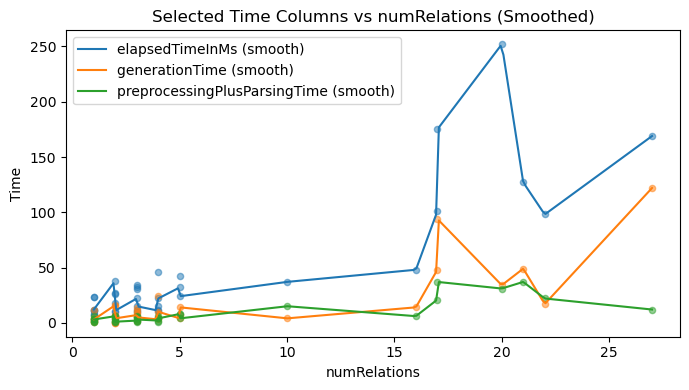

In [12]:
import matplotlib.pyplot as plt
import numpy as np

time_cols = selected_time if "selected_time" in globals() else []

candidate_x_cols = ["numOfRelations", "numRelations"]
x_col = next((c for c in candidate_x_cols if c in avg_times_per_model.columns), None)

if len(time_cols) == 0 or x_col is None:
    print("Missing time columns or relation-count column for combined chart.")
else:
    plot_df = avg_times_per_model[[x_col] + time_cols].dropna()
    plot_df = plot_df.sort_values(by=x_col)

    x = plot_df[x_col].to_numpy()
    if len(np.unique(x)) < 2:
        print("Not enough unique x values to smooth the chart.")
    else:
        x_dense = np.linspace(x.min(), x.max(), 200)
        plt.figure(figsize=(7, 4))
        for tcol in time_cols:
            y = plot_df[tcol].to_numpy()
            y_dense = np.interp(x_dense, x, y)
            plt.plot(x_dense, y_dense, label=f"{tcol} (smooth)")
            plt.scatter(x, y, s=20, alpha=0.5)
        plt.xlabel(x_col)
        plt.ylabel("Time")
        plt.title(f"Selected Time Columns vs {x_col} (Smoothed)")
        plt.legend()
        plt.tight_layout()
        plt.show()